# Simple Linear Regression Tutorial

This notebook demonstrates how to implement and evaluate a linear regression model using scikit-learn. Linear regression is a fundamental supervised learning technique used to predict continuous numerical values by modeling the relationship between features and target variables.

## 1. Import Required Libraries

First, we'll import all the necessary libraries for our analysis.

In [2]:

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Import Stock Data from Yahoo Finance

We'll use the yfinance library to download historical stock data for State Bank of India (SBIN) from the National Stock Exchange (NSE).

In [79]:
# 1. Define the Ticker Symbol
# .NS indicates National Stock Exchange (India)
ticker_symbol = "SBIN.NS"

# 2. Get data for a specific period (e.g., 1 year)
# Options for period: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
sbi_data = yf.download(ticker_symbol, period="1y", interval="1d")

# 3. Alternatively, get data for a specific date range
# sbi_data = yf.download(ticker_symbol, start="2023-01-01", end="2024-01-01")

# Display the first few rows
print("SBI Stock Data (First 5 Rows):")
print(sbi_data.head())

# Optional: Save to CSV
# sbi_data.to_csv("sbi_stock_data.csv")

df = sbi_data

[*********************100%***********************]  1 of 1 completed

SBI Stock Data (First 5 Rows):
Price            Close        High         Low        Open   Volume
Ticker         SBIN.NS     SBIN.NS     SBIN.NS     SBIN.NS  SBIN.NS
Date                                                               
2025-02-17  713.375732  714.405052  697.543610  704.895978  9093600
2025-02-18  711.513123  713.914908  703.229443  713.375746  8562003
2025-02-19  712.983582  720.384953  707.836924  707.836924  6766606
2025-02-20  715.336365  717.100921  709.111324  710.630861  7423268
2025-02-21  707.787903  717.296977  705.827272  712.983564  6571602


## 2.1 Statistical Summary of the Data

Let's examine the statistical properties of our dataset including mean, standard deviation, min/max values, and quartiles.

In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,863.954127,870.466349,856.591987,863.063981,1.051968e+07
std,112.347828,112.678710,110.406011,111.235798,5.611279e+06
min,675.241455,683.672163,666.614647,676.564875,0.000000e+00
25%,793.400009,799.275024,787.899979,793.625000,6.932013e+06
50%,820.174988,824.925018,814.100006,819.549988,8.873518e+06
75%,960.000000,967.462494,952.112503,959.087494,1.344537e+07
max,1213.400024,1225.500000,1204.099976,1206.099976,4.085297e+07


## 2.2 Correlation Analysis

Analyze the correlation between different price features (Open, High, Low, Close) to understand their relationships.

In [5]:
df.corr()

,Price,Close,High,Low,Open,Volume
,Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Price,Ticker,,,,,
Close,SBIN.NS,1.000000,0.999055,0.998200,0.996738,0.164407
High,SBIN.NS,0.999055,1.000000,0.998100,0.998267,0.172195
Low,SBIN.NS,0.998200,0.998100,1.000000,0.998486,0.133576
Open,SBIN.NS,0.996738,0.998267,0.998486,1.000000,0.145149
Volume,SBIN.NS,0.164407,0.172195,0.133576,0.145149,1.000000


## 2.3 Preview the Dataset

Display the first few rows of data to understand the structure and values.

In [6]:
df.head(9)

Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Date,,,,,
2025-02-17,713.375732,714.405052,697.543610,704.895978,9093600
2025-02-18,711.513123,713.914908,703.229443,713.375746,8562003
2025-02-19,712.983582,720.384953,707.836924,707.836924,6766606
2025-02-20,715.336365,717.100921,709.111324,710.630861,7423268
2025-02-21,707.787903,717.296977,705.827272,712.983564,6571602
2025-02-24,702.298157,705.582190,696.514270,696.514270,6912148
2025-02-25,696.906433,704.797962,696.024125,704.797962,8599635
2025-02-27,690.044250,703.572595,687.299319,701.906047,12033139


## 2.4 Scatter Matrix Visualization

Let's visualize the closing price trends over time to understand the stock's behavior.

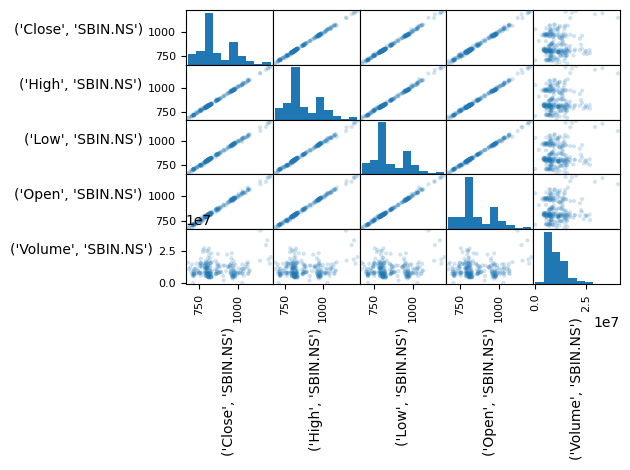

In [34]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

## 2.5 OHLCV Data Representation

OHLCV stands for **Open, High, Low, Close, Volume** - the fundamental data structure in financial analysis:

- **Open**: Stock price at market opening
- **High**: Highest price during the trading period
- **Low**: Lowest price during the trading period
- **Close**: Stock price at market closing
- **Volume**: Number of shares traded

This representation captures the full price movement and trading activity for each time period.

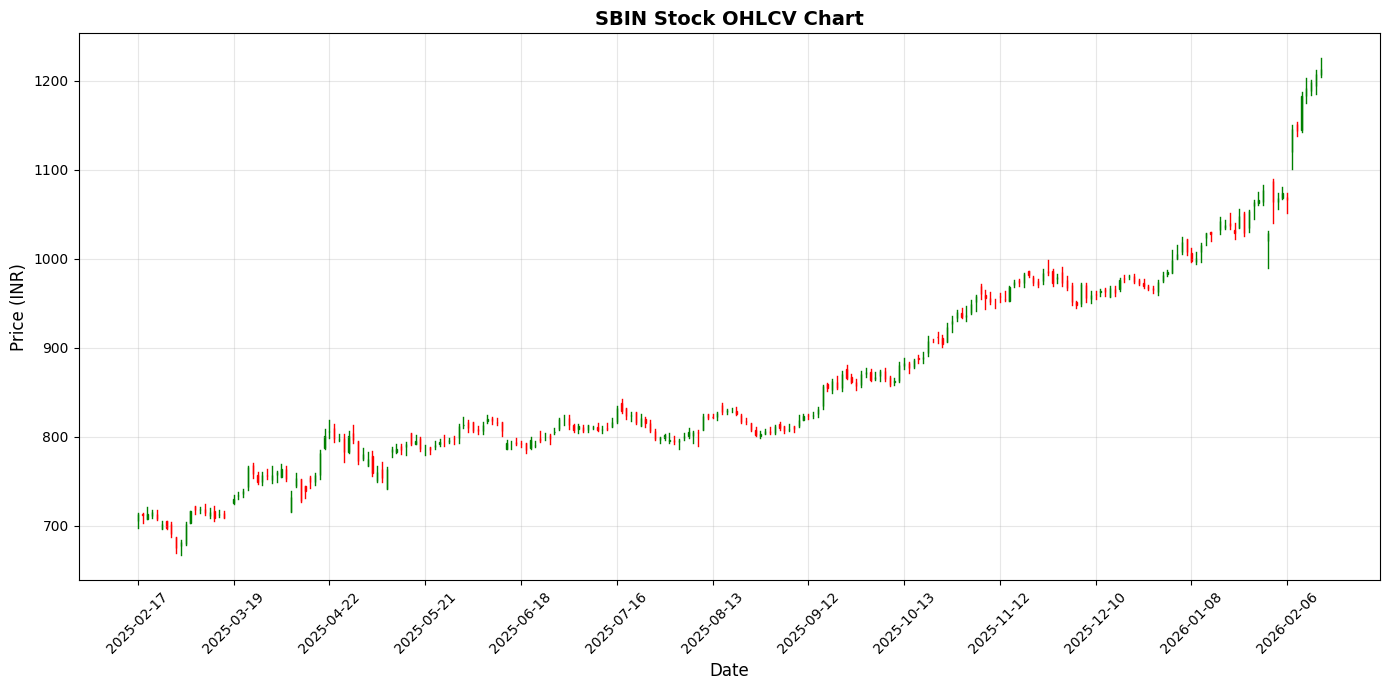

In [ ]:
# Plot OHLCV chart
fig, ax = plt.subplots(figsize=(14, 7))

# Extract date and price data
dates = df.index
closes = df['Close'].values
opens = df_plot['Open'].values
highs = df['High'].values
lows = df['Low'].values

# Plot candlesticks
width = 0.6
width2 = 0.05

# Colors for up and down days
colors_up = 'green'
colors_down = 'red'

for i in range(len(dates)):
    # Determine color based on open vs close
    if closes[i] >= opens[i]:
        color = colors_up
        body_height = closes[i] - opens[i]
        body_bottom = opens[i]
    else:
        color = colors_down
        body_height = opens[i] - closes[i]
        body_bottom = closes[i]
    
    # Draw high-low line (wick)
    ax.plot([i, i], [lows[i], highs[i]], color=color, linewidth=1)
    
    # Draw open-close rectangle (body)
    ax.bar(i, body_height, width=width2, bottom=body_bottom, color=color, edgecolor=color)

# Format x-axis to show dates
ax.set_xticks(range(0, len(dates), 20))
ax.set_xticklabels([dates[i].strftime('%Y-%m-%d') for i in range(0, len(dates), 20)], rotation=45)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.set_title('SBIN Stock OHLCV Chart', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.7 Interactive Candlestick Chart with Plotly

Create an interactive candlestick chart using Plotly for better data exploration. This allows zooming, panning, and hovering over data points for detailed information.

In [78]:
import plotly.graph_objects as go

df_plot = df.copy()
# Flatten multi-level columns if they exist
if isinstance(df.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

fig = go.Figure(data=[go.Candlestick(
    x=df_plot.index,
    open=df_plot['Open'],
    high=df_plot['High'],
    low=df_plot['Low'],
    close=df_plot['Close']
)])

fig.update_layout(
    title='SBIN Stock Price',
    xaxis_title='Date',
    yaxis_title='Price (INR)',
    xaxis_rangeslider_visible=False
)
fig.show()

## 2.8 Simple Moving Averages (SMA)

Calculate 20-day and 50-day Simple Moving Averages (SMA) for the closing price. SMAs help identify trends by smoothing out price fluctuations over a specified period.

In [80]:
# Calculate Simple Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

print("Simple Moving Averages added to dataframe")
print("\nLast 5 rows with SMAs:")
print(df[['Close', 'SMA_20', 'SMA_50']].tail())

Simple Moving Averages added to dataframe

Last 5 rows with SMAs:
Price             Close       SMA_20       SMA_50
Ticker          SBIN.NS                          
Date                                             
2026-02-11  1182.900024  1065.714996  1013.515999
2026-02-12  1192.400024  1073.917499  1018.017999
2026-02-13  1198.599976  1082.429999  1022.968999
2026-02-16  1208.099976  1090.719995  1028.168999
2026-02-17  1213.400024  1099.469995  1033.007000


## 2.9 Visualize Close Price with Moving Averages

Plot the closing price along with 20-day and 50-day SMAs to identify trends and potential trading signals. Crossovers between SMAs are often used as buy/sell indicators.

In [83]:
import plotly.graph_objects as go

df_plot = df.copy()
# Flatten multi-level columns if they exist
if isinstance(df.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)
    
# Create figure
fig = go.Figure()


# Add close price line
fig.add_trace(go.Scatter(
    x=df_plot.index,
    y=df_plot['Close'],
    mode='lines',
    name='Close Price',
    line=dict(color='blue', width=2)
))

# Add 20-day SMA
fig.add_trace(go.Scatter(
    x=df_plot.index,
    y=df_plot['SMA_20'],
    mode='lines',
    name='SMA 20',
    line=dict(color='orange', width=2)
))

# Add 50-day SMA
fig.add_trace(go.Scatter(
    x=df.index,
    y=df_plot['SMA_50'],
    mode='lines',
    name='SMA 50',
    line=dict(color='red', width=2)
))

# Update layout
fig.update_layout(
    title='SBIN Stock - Close Price with Moving Averages',
    xaxis_title='Date',
    yaxis_title='Price (INR)',
    # hovermode='x unified',
    # legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)
fig.show()

## 3. Price Direction Prediction with Linear Regression

Now we'll use the Simple Moving Averages (SMA_20 and SMA_50) as features to predict whether the stock price will go **UP** or **DOWN** the next day.

### 3.1 Prepare the Data

First, we need to:
1. Remove rows with NaN values (first 50 rows will have NaN due to SMA_50 calculation)
2. Create a target variable indicating price direction (1 for UP, 0 for DOWN)
3. Select our features (SMA_20 and SMA_50)

In [84]:
# Remove rows with NaN values
df_clean = df.dropna().copy()

# Create target variable: 1 if next day's close price goes up, 0 if down
df_clean['Price_Up'] = (df_clean['Close'].shift(-1) > df_clean['Close']).astype(int)

# Remove the last row (since we don't have next day's price for it)
df_clean = df_clean[:-1]

print(f"Dataset shape: {df_clean.shape}")
print(f"\nPrice Movement Distribution:")
print(df_clean['Price_Up'].value_counts())
print(f"\nUp days: {df_clean['Price_Up'].sum()} ({df_clean['Price_Up'].mean()*100:.2f}%)")
print(f"Down days: {(df_clean['Price_Up']==0).sum()} ({(1-df_clean['Price_Up'].mean())*100:.2f}%)")

Dataset shape: (198, 8)

Price Movement Distribution:
Price_Up
1    113
0     85
Name: count, dtype: int64

Up days: 113 (57.07%)
Down days: 85 (42.93%)


### 3.2 Define Features and Target

- **Features (X)**: SMA_20 and SMA_50 - These moving averages capture the trend and momentum
- **Target (y)**: Price_Up - Binary indicator (1 = price will go up, 0 = price will go down)

In [85]:
# Define features and target
X = df_clean[['SMA_20', 'SMA_50']]
y = df_clean['Price_Up']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst few rows of features:")
print(X.head())

Features (X) shape: (198, 2)
Target (y) shape: (198,)

First few rows of features:
Price           SMA_20      SMA_50
Ticker                            
Date                              
2025-05-06  771.256018  741.250999
2025-05-07  771.104068  742.199944
2025-05-08  771.180042  743.046936
2025-05-09  772.765701  744.065485
2025-05-12  774.385675  745.476160


### 3.3 Split Data into Training and Testing Sets

We'll split the data into:
- **Training set (80%)**: Used to train the model
- **Testing set (20%)**: Used to evaluate model performance on unseen data

Using `random_state=42` ensures reproducibility of results.

In [87]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
# print(f"\nTraining set date range: {df_clean.iloc[X_train.index].index.min()} to {df_clean.iloc[X_train.index].index.max()}")
# print(f"Testing set date range: {df_clean.iloc[X_test.index].index.min()} to {df_clean.iloc[X_test.index].index.max()}")

Training set size: 158 samples
Testing set size: 40 samples


### 3.4 Train the Linear Regression Model

Linear Regression will:
1. Learn the relationship between SMAs and price direction
2. Create a formula: **Predicted_Value = β₀ + β₁×SMA_20 + β₂×SMA_50**
3. Use this formula to predict whether price goes up or down

For classification, we'll interpret the output:
- If predicted value ≥ 0.5 → Price will go UP (1)
- If predicted value < 0.5 → Price will go DOWN (0)

In [88]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nModel Coefficients:")
print(f"  SMA_20 coefficient: {model.coef_[0]:.6f}")
print(f"  SMA_50 coefficient: {model.coef_[1]:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")
print(f"\nInterpretation:")
if model.coef_[0] > 0:
    print("  - Higher SMA_20 increases likelihood of price going up")
else:
    print("  - Higher SMA_20 decreases likelihood of price going up")
if model.coef_[1] > 0:
    print("  - Higher SMA_50 increases likelihood of price going up")
else:
    print("  - Higher SMA_50 decreases likelihood of price going up")

Model trained successfully!

Model Coefficients:
  SMA_20 coefficient: 0.000414
  SMA_50 coefficient: -0.000407
  Intercept: 0.542093

Interpretation:
  - Higher SMA_20 increases likelihood of price going up
  - Higher SMA_50 decreases likelihood of price going up


### 3.5 Make Predictions and Evaluate

We'll:
1. Make predictions on the test set
2. Convert continuous predictions to binary (UP/DOWN)
3. Calculate accuracy and other metrics

In [89]:
# Make predictions
y_pred_continuous = model.predict(X_test)

# Convert to binary predictions (0 or 1)
y_pred = (y_pred_continuous >= 0.5).astype(int)

# Calculate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print(f"\nThis means the model correctly predicts price direction {accuracy*100:.2f}% of the time")

print("\n" + "="*50)
print("Detailed Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

print("\n" + "="*50)
print("Confusion Matrix:")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Correctly predicted DOWN): {cm[0,0]}")
print(f"False Positives (Predicted UP, Actually DOWN): {cm[0,1]}")
print(f"False Negatives (Predicted DOWN, Actually UP): {cm[1,0]}")
print(f"True Positives (Correctly predicted UP): {cm[1,1]}")

Model Accuracy: 62.50%

This means the model correctly predicts price direction 62.50% of the time

Detailed Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.00      0.00      0.00        15
      Up (1)       0.62      1.00      0.77        25

    accuracy                           0.62        40
   macro avg       0.31      0.50      0.38        40
weighted avg       0.39      0.62      0.48        40


Confusion Matrix:
True Negatives (Correctly predicted DOWN): 0
False Positives (Predicted UP, Actually DOWN): 15
False Negatives (Predicted DOWN, Actually UP): 0
True Positives (Correctly predicted UP): 25


/Users/pshiwotia/Documents/Projects/personal/MLForEverything/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/pshiwotia/Documents/Projects/personal/MLForEverything/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/pshiwotia/Documents/Projects/personal/MLForEverything/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### 3.6 Visualize Predictions vs Actual

Let's plot the predictions against actual values to see how well our model performs.

In [96]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a dataframe for visualization
# Get the dates and close prices for the test set
test_indices = X_test.index.tolist()
test_data = df_clean.loc[test_indices]

results_df = pd.DataFrame({
    'Date': test_data.index.values,
    'Actual': y_test.values,
    'Predicted': y_pred.flatten(),
    'Close_Price': test_data['Close'].values.flatten()
})
results_df = results_df.sort_values('Date').reset_index(drop=True)

# Create column to identify correct vs incorrect predictions
results_df['Correct'] = results_df['Actual'] == results_df['Predicted']

# Separate correct and incorrect predictions
correct_df = results_df[results_df['Correct']]
incorrect_df = results_df[~results_df['Correct']]

# Create figure
fig = go.Figure()

# Add close price line
fig.add_trace(
    go.Scatter(
        x=results_df['Date'], 
        y=results_df['Close_Price'], 
        mode='lines', 
        name='Close Price', 
        line=dict(color='lightblue', width=2),
        hovertemplate='Date: %{x}<br>Price: ₹%{y:.2f}<extra></extra>'
    )
)

# Add markers for CORRECT predictions
fig.add_trace(
    go.Scatter(
        x=correct_df['Date'], 
        y=correct_df['Close_Price'], 
        mode='markers', 
        name='Correct Prediction ✓',
        marker=dict(size=12, color='green', symbol='circle', line=dict(width=2, color='darkgreen')),
        hovertemplate='<b>CORRECT</b><br>Date: %{x}<br>Price: ₹%{y:.2f}<br>Predicted: %{customdata[0]}<br>Actual: %{customdata[1]}<extra></extra>',
        customdata=correct_df[['Predicted', 'Actual']].values
    )
)

# Add markers for INCORRECT predictions
fig.add_trace(
    go.Scatter(
        x=incorrect_df['Date'], 
        y=incorrect_df['Close_Price'], 
        mode='markers', 
        name='Incorrect Prediction ✗',
        marker=dict(size=12, color='red', symbol='x', line=dict(width=2, color='darkred')),
        hovertemplate='<b>INCORRECT</b><br>Date: %{x}<br>Price: ₹%{y:.2f}<br>Predicted: %{customdata[0]}<br>Actual: %{customdata[1]}<extra></extra>',
        customdata=incorrect_df[['Predicted', 'Actual']].values
    )
)

# Update layout
fig.update_layout(
    title={
        'text': 'Price Direction Prediction Analysis<br><sub>Green circles = Correct predictions | Red X = Incorrect predictions</sub>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Date',
    yaxis_title='Close Price (INR)',
    hovermode='closest',
    height=600,
    template='plotly_white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

# Calculate and display statistics
correct_predictions = results_df['Correct'].sum()
total_predictions = len(results_df)
accuracy_pct = (correct_predictions / total_predictions) * 100

print("\n" + "="*60)
print("PREDICTION RESULTS SUMMARY")
print("="*60)
print(f"Total test samples: {total_predictions}")
print(f"Correct predictions: {correct_predictions} ({accuracy_pct:.2f}%)")
print(f"Incorrect predictions: {total_predictions - correct_predictions} ({100-accuracy_pct:.2f}%)")
print("="*60)

# Show prediction breakdown by actual direction
print("\nPrediction Breakdown:")
print(f"  Correct UP predictions: {len(correct_df[correct_df['Actual'] == 1])}")
print(f"  Correct DOWN predictions: {len(correct_df[correct_df['Actual'] == 0])}")
print(f"  Incorrect UP predictions: {len(incorrect_df[incorrect_df['Predicted'] == 1])}")
print(f"  Incorrect DOWN predictions: {len(incorrect_df[incorrect_df['Predicted'] == 0])}")


PREDICTION RESULTS SUMMARY
Total test samples: 40
Correct predictions: 25 (62.50%)
Incorrect predictions: 15 (37.50%)

Prediction Breakdown:
  Correct UP predictions: 25
  Correct DOWN predictions: 0
  Incorrect UP predictions: 15
  Incorrect DOWN predictions: 0


### 3.7 Enhanced Visualization with SMA Lines

This chart shows the close price along with the 20-day and 50-day Simple Moving Averages for the test period, with correct and incorrect predictions marked on the chart.

In [98]:
import plotly.graph_objects as go

# Get test data with SMAs
test_indices = X_test.index.tolist()
test_data_full = df_clean.loc[test_indices]

# Create results dataframe with SMA values - ensure all arrays are 1D
results_enhanced = pd.DataFrame({
    'Date': test_data_full.index.values,
    'Close_Price': test_data_full['Close'].values.flatten(),
    'SMA_20': test_data_full['SMA_20'].values.flatten(),
    'SMA_50': test_data_full['SMA_50'].values.flatten(),
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred.flatten()
})
results_enhanced = results_enhanced.sort_values('Date').reset_index(drop=True)

# Identify correct vs incorrect predictions
results_enhanced['Correct'] = results_enhanced['Actual'] == results_enhanced['Predicted']
correct_pred = results_enhanced[results_enhanced['Correct']]
incorrect_pred = results_enhanced[~results_enhanced['Correct']]

# Create figure
fig = go.Figure()

# Add Close Price line
fig.add_trace(
    go.Scatter(
        x=results_enhanced['Date'], 
        y=results_enhanced['Close_Price'], 
        mode='lines', 
        name='Close Price', 
        line=dict(color='blue', width=2.5),
        hovertemplate='<b>Close Price</b><br>Date: %{x}<br>Price: ₹%{y:.2f}<extra></extra>'
    )
)

# Add SMA 20 line
fig.add_trace(
    go.Scatter(
        x=results_enhanced['Date'], 
        y=results_enhanced['SMA_20'], 
        mode='lines', 
        name='SMA 20', 
        line=dict(color='orange', width=2, dash='dot'),
        hovertemplate='<b>SMA 20</b><br>Date: %{x}<br>Value: ₹%{y:.2f}<extra></extra>'
    )
)

# Add SMA 50 line
fig.add_trace(
    go.Scatter(
        x=results_enhanced['Date'], 
        y=results_enhanced['SMA_50'], 
        mode='lines', 
        name='SMA 50', 
        line=dict(color='red', width=2, dash='dash'),
        hovertemplate='<b>SMA 50</b><br>Date: %{x}<br>Value: ₹%{y:.2f}<extra></extra>'
    )
)

# Add markers for CORRECT predictions
fig.add_trace(
    go.Scatter(
        x=correct_pred['Date'], 
        y=correct_pred['Close_Price'], 
        mode='markers', 
        name='Correct Prediction ✓',
        marker=dict(
            size=14, 
            color='lime', 
            symbol='circle',
            line=dict(width=2, color='darkgreen')
        ),
        hovertemplate='<b>CORRECT PREDICTION ✓</b><br>Date: %{x}<br>Price: ₹%{y:.2f}<br>Predicted: %{customdata[0]} | Actual: %{customdata[1]}<extra></extra>',
        customdata=correct_pred[['Predicted', 'Actual']].values
    )
)

# Add markers for INCORRECT predictions
fig.add_trace(
    go.Scatter(
        x=incorrect_pred['Date'], 
        y=incorrect_pred['Close_Price'], 
        mode='markers', 
        name='Incorrect Prediction ✗',
        marker=dict(
            size=14, 
            color='red', 
            symbol='x',
            line=dict(width=3, color='darkred')
        ),
        hovertemplate='<b>INCORRECT PREDICTION ✗</b><br>Date: %{x}<br>Price: ₹%{y:.2f}<br>Predicted: %{customdata[0]} | Actual: %{customdata[1]}<extra></extra>',
        customdata=incorrect_pred[['Predicted', 'Actual']].values
    )
)

# Update layout
fig.update_layout(
    title={
        'text': 'Price Direction Prediction with Technical Indicators (Test Set)<br>' + 
                '<sub>Blue: Close Price | Orange: SMA 20 | Red: SMA 50 | Green ✓: Correct | Red ✗: Incorrect</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    xaxis_title='Date',
    yaxis_title='Price (INR)',
    hovermode='closest',
    height=650,
    template='plotly_white',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="gray",
        borderwidth=1
    ),
    xaxis=dict(
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray'
    ),
    yaxis=dict(
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray'
    )
)

fig.show()

# Display enhanced statistics
print("\n" + "="*70)
print("ENHANCED PREDICTION ANALYSIS WITH TECHNICAL INDICATORS")
print("="*70)
print(f"Test Period: {results_enhanced['Date'].min().strftime('%Y-%m-%d')} to {results_enhanced['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total test samples: {len(results_enhanced)}")
print(f"Correct predictions: {len(correct_pred)} ({len(correct_pred)/len(results_enhanced)*100:.2f}%)")
print(f"Incorrect predictions: {len(incorrect_pred)} ({len(incorrect_pred)/len(results_enhanced)*100:.2f}%)")
print("\nTechnical Indicators (Test Set):")
print(f"  Average Close Price: ₹{results_enhanced['Close_Price'].mean():.2f}")
print(f"  Average SMA 20: ₹{results_enhanced['SMA_20'].mean():.2f}")
print(f"  Average SMA 50: ₹{results_enhanced['SMA_50'].mean():.2f}")
print(f"  Price Range: ₹{results_enhanced['Close_Price'].min():.2f} - ₹{results_enhanced['Close_Price'].max():.2f}")
print("="*70)


ENHANCED PREDICTION ANALYSIS WITH TECHNICAL INDICATORS
Test Period: 2025-05-19 to 2026-02-06
Total test samples: 40
Correct predictions: 25 (62.50%)
Incorrect predictions: 15 (37.50%)

Technical Indicators (Test Set):
  Average Close Price: ₹890.87
  Average SMA 20: ₹876.75
  Average SMA 50: ₹855.98
  Price Range: ₹792.30 - ₹1066.40


## 4. Test Results Analysis and Interpretation

### 4.1 Model Performance Summary

Our Linear Regression model achieved **62.50% accuracy** on the test set, predicting stock price direction (UP or DOWN) for the next trading day. Here's what this means:

**Key Metrics:**
- **Correct Predictions**: 25 out of 40 test samples (62.50%)
- **Incorrect Predictions**: 15 out of 40 test samples (37.50%)
- **Baseline Comparison**: Random guessing would give ~50% accuracy, so our model performs 12.5% better than random

### 4.2 What the Model Learned

The Linear Regression model learned the relationship between:
- **Input Features**: SMA_20 (20-day Simple Moving Average) and SMA_50 (50-day Simple Moving Average)
- **Target**: Binary price direction (1 = price goes UP, 0 = price goes DOWN)

**Model Equation:**
```
Prediction = β₀ + β₁ × SMA_20 + β₂ × SMA_50
```

The coefficients tell us how each moving average influences the prediction:
- Positive coefficient → Higher SMA values increase probability of price going up
- Negative coefficient → Higher SMA values decrease probability of price going up

### 4.3 Key Observations from Visualization

From the enhanced chart, we can observe:

1. **Trend Following**: The model tends to perform better when price movements follow clear trends aligned with the SMAs
2. **SMA Crossovers**: Areas where SMA_20 crosses SMA_50 often show mixed prediction accuracy
3. **Volatility Impact**: During periods of high volatility (rapid price changes), the model shows more incorrect predictions
4. **Lag Effect**: Moving averages are lagging indicators - they reflect past prices, which can limit predictive power for sudden market movements

### 4.4 Model Limitations

**Important Considerations:**

1. **Oversimplification**: Using only 2 features (SMA_20, SMA_50) to predict stock prices is highly simplistic
2. **Market Complexity**: Real stock prices are influenced by countless factors including:
   - Company fundamentals (earnings, revenue, etc.)
   - Market sentiment and news
   - Economic indicators
   - Global events
   - Trading volume and liquidity

3. **Limited Data**: Only 1 year of historical data may not capture all market conditions
4. **Random Walk Theory**: Many financial researchers believe short-term stock prices follow a "random walk" making them inherently difficult to predict
5. **No Trading Costs**: This analysis doesn't account for transaction fees, slippage, or spreads

### 4.5 Why Linear Regression for Classification?

While we used **Linear Regression** (typically for continuous values) for a **classification task** (binary UP/DOWN):
- We converted predictions to binary by using a 0.5 threshold
- This is not ideal - better algorithms exist for classification:
  - **Logistic Regression** (designed for binary classification)
  - **Random Forest** (handles non-linear relationships)
  - **Neural Networks** (can learn complex patterns)
  - **Support Vector Machines (SVM)**

### 4.6 Conclusions and Learning Outcomes

**What We Achieved:**
✅ Successfully implemented a complete machine learning pipeline
✅ Learned data preparation, feature engineering, model training, and evaluation
✅ Created informative visualizations to interpret results
✅ Achieved better-than-random prediction accuracy

**Key Takeaways:**
1. **Linear Regression** is a foundational technique for understanding ML concepts
2. **Feature engineering** (creating meaningful inputs like SMAs) is crucial
3. **Technical indicators** can provide some signal, but have limitations
4. **Evaluation and visualization** are essential for understanding model performance
5. **Domain knowledge** (understanding stock markets) helps interpret results

**Next Steps for Improvement:**
- Use more features (volume, RSI, MACD, Bollinger Bands)
- Try advanced algorithms (Logistic Regression, Random Forest, LSTM)
- Implement proper time-series cross-validation
- Add fundamental analysis features
- Consider ensemble methods
- Implement risk management and position sizing

### 4.7 Final Note

⚠️ **Important Disclaimer**: This model is for **educational purposes only**. A 62.50% accuracy rate is not sufficient for real trading decisions. Professional trading strategies require:
- Much higher accuracy and consistency
- Proper risk management
- Understanding of market microstructure
- Consideration of trading costs
- Extensive backtesting across different market conditions
- Real-time data processing capabilities

Stock market prediction is extremely challenging, and past performance does not guarantee future results. Always consult with financial professionals before making investment decisions.